## 3DoF Entry Cobra w/o Aoa SCP

Imports

In [ ]:
# Basic imports
import importlib
import numpy                as np
import matplotlib.pyplot    as plt
import pandas               as pd
import copy

# Trajopt imports --> pip install -e ~/ACL/trajopt
import trajopt; importlib.reload(trajopt)
import trajopt.core.modules.method.scp              as scp
import trajopt.core.problem                         as prob
import trajopt.utils.config_loader                  as cfg
import trajopt.utils.tools                          as tools
import trajopt.analysis.default_analysis            as default_analysis
import trajopt.analysis.statistics                  as stats
import trajopt.core.modules.analysis.monte_carlo    as mc

from trajopt.analysis.trajplots import *

from trajopt.analysis.custom_functions_danb import max_q_nonjax, max_Q_nonjax, max_load_nonjax, terminal_cost
from trajopt.analysis.plots_for_scitech26b import *

np.random.seed(0)  # for reproducibility



/Users/dan/Documents/skye/cobradata/examples/cobra_entry_3dof/plots_for_scitech26.py:96: SyntaxWarning: invalid escape sequence '\s'
  ylabels[0] = 'Bank Angle, $\sigma$ [deg]';
/Users/dan/Documents/skye/cobradata/examples/cobra_entry_3dof/plots_for_scitech26.py:236: SyntaxWarning: invalid escape sequence '\s'
  ylabels[0] = 'Bank Angle, $\sigma$ [deg]';
/Users/dan/Documents/skye/cobradata/examples/cobra_entry_3dof/plots_for_scitech26.py:382: SyntaxWarning: invalid escape sequence '\p'
  xlabels[0] = 'Latitude $\phi$ [deg]';
/Users/dan/Documents/skye/cobradata/examples/cobra_entry_3dof/plots_for_scitech26.py:387: SyntaxWarning: invalid escape sequence '\p'
  ylabels[1] = 'Latitude $\phi$ [deg]';
/Users/dan/Documents/skye/cobradata/examples/cobra_entry_3dof/plots_for_scitech26.py:618: SyntaxWarning: invalid escape sequence '\p'
  ylabels[3] = 'Heading $\psi$ [deg]';


setup problem and run SCP

In [2]:
example_name = "cobra_entry_3dof"
nominal_config  = cfg.load_configs(example_name,local=True)

# either generate mc variations from yamls or load existing saved mc variations
gen_mc_variations    = 1

# save mc variations to file (specificy a name for this set of mc variations as well)
save_mc_variations   = 0
mc_name = "mc1"

# save scenario data to file (save the scenario data struct)
save_scenario_data   = 0

# run mc analysis loop
# TODO(Carlos and  Dan):  shouldn't need to return problem, just scenario data, something below depends on it though (this is the most recent problem instance)
scenario_data, problem = mc.run_mc_analysis(example_name, nominal_config, gen_mc_variations, save_mc_variations, save_scenario_data, mc_name,local=True)

scales: 
d: 3396190.0000, t: 956.3609, m: 61838.1000, v: 3551.1593, a: 3.7132, f: 229617.2329, ang: 57.2958, angv: 0.0599
Initial guess time: 0.46201162500074133 seconds
Cost initial: 0.8227226057829633
--------------------------------------------------------------------------------------------------------------------------------------------------------
                                              ..:: cobra: PTR with Virtual Buffer ::..
--------------------------------------------------------------------------------------------------------------------------------------------------------
  Iteration |  Propagation |   Solve   |    Parse   |  log(dz)  |      log(VB)    |   log(VB)   |  log(VB)    | Solve status |  Time of    |   Cost    
            |   time [ms]  | time [ms] |  time [ms] |           |  (path + NFZ)   |  (terminal) |  (dynamics) |              |  Flight [s] |           
----------------------------------------------------------------------------------------------------

/Users/dan/miniconda3/envs/numpy2env/lib/python3.13/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:41: UserWarning: The problem has an expression with dimension greater than 2. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(


     01     |    01824.6   |   0003.6  |   0147.7   |   -2.3    |      -12.0      |    -01.8    |     -12.0   |    optimal    |   452.85   |  2633.1
     02     |    00005.0   |   0004.8  |   0000.6   |   -2.2    |      -12.0      |    -02.0    |     -12.0   |    optimal    |   402.85   |  2008.3
     03     |    00003.7   |   0003.9  |   0000.6   |   -2.6    |      -12.0      |    -01.9    |     -12.0   |    optimal    |   356.56   |  2202.2
     04     |    00003.2   |   0005.5  |   0000.7   |   -1.9    |      -12.0      |    -03.0    |     -12.0   |    optimal    |   322.52   |  2162.1
     05     |    00004.4   |   0003.8  |   0000.6   |   -2.4    |      -12.0      |    -05.5    |     -12.0   |    optimal    |   357.11   |  754.4
     06     |    00003.8   |   0007.1  |   0001.3   |   -2.9    |      -12.0      |    -05.5    |     -12.0   |    optimal    |   373.66   |  651.8
     07     |    00003.4   |   0004.1  |   0000.6   |   -3.0    |      -12.0      |    -05.3    |     -12.0 

mc analysis

In [3]:
# file = '~/masters-link/ACL/prototypes/trajopt/src/trajopt/examples/vtol1_entry_3dof/data/statistics/mc1.txt' # Example file
# analysis = stats.analyze_quality_metrics(scenario_data, filename=file)

# Can run without filename if you don't want to save LaTeX tables
analysis = stats.analyze_quality_metrics(scenario_data)

Extracting data from runs...
Computing statistics across runs...
Generating statistic tables...
Plotting tables...

=== No. of Iteration ===

         standard   autotune
Max     17.000000  10.000000
Mean    13.000000   9.500000
Median  13.000000   9.500000
Min      9.000000   9.000000
Mode     9.000000   9.000000
Std      5.656854   0.707107
Var     32.000000   0.500000


=== Solve Time/Iteration (ms/iter) ===

        standard  autotune
Max     4.512217  6.745032
Mean    3.863290  6.678362
Median  3.863290  6.678362
Min     3.214362  6.611691
Mode    3.214362  6.611691
Std     0.917722  0.094286
Var     0.842214  0.008890


=== Parse Time/Iteration (ms/iter) ===

         standard   autotune
Max     17.033921  27.560616
Mean    12.682603  27.169140
Median  12.682603  27.169140
Min      8.331285  26.777665
Mode     8.331285  26.777665
Std      6.153693   0.553630
Var     37.867941   0.306506


=== Propagation Time/Iteration (ms/iter) ===

           standard     autotune
Max      206.

# Load data and preprocess... (compute loads...)

In [4]:
data = {'scenario1':scenario_data}
PLTS1 = SCVXPLOTS(data);
preProcess(PLTS1,problem);
    

# DASHBOARD

In [18]:
%load_ext autoreload
%autoreload 2

versions = ['montecarlo'];
figpaths = ['figs/mvmc/'];

displayfigs = True;
printfigs = True; 
transparentfigs = True; 

specs = {}

specs['standalone'] = {'methods':['autotune'],'runs':[0],'itrs':[]};
specs['sa_iters'] = {'methods':['autotune'],'runs':[0],'itrs':list(range(1000))[1:]};
specs['methodvar'] = {'methods':['standard','autotune'],'runs':[0]}; #,'itrs':list(range(1000))[1:]};
specs['mvmc'] = {'methods':['standard','autotune'],'runs':list(range(10))}; #,'itrs':list(range(1000))[1:]};
specs['montecarlo'] = {'methods':['autotune'],'runs':list(range(1000))}; #'itrs':list(range(1000))[1:]};

######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- 
######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- 
######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- 

## default pens are set in the function plots_for_scitech26.py
## set new pens here. 
PENS = {};  
PENS['newpen'] = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,.0,1.],'lw':1,'ls':'--','msty':'' ,'msz':3};

## common pens to change
PENS['init'] = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,.0,1.],'lw':1,'ls':'--','msty':'' ,'msz':3};
PENS['itr']  = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,1.,.2],'lw':1,'ls':'--','msty':'' ,'msz':3};
PENS['opt']  = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,1.,1.],'lw':1,'ls':''  ,'msty':'o','msz':3};
PENS['prop'] = {'frgba':[.0,.0,.0,.1],'lrgba':[1.,.0,.0,1.],'lw':1,'ls':'-' ,'msty':'' ,'msz':3};
PENS['ref']  = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,.0,1.],'lw':1,'ls':'--','msty':'*','msz':3};
PENS['standard']  = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,1.,1.],'lw':1,'ls':'-','msty':'o','msz':3};
PENS['autotune']  = {'frgba':[.0,.0,.0,.1],'lrgba':[1.,.0,1.,1.],'lw':1,'ls':'-','msty':'o','msz':3};

## weight pens (not currently in use)
# PENS['opt_weight']      = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,1.,1.],'lw':1,'ls':'-'  ,'msty':'o','msz':3};
# PENS['opt_weight_0']    = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,1.,1.],'lw':1,'ls':'-'  ,'msty':'o','msz':3};
# PENS['opt_weight_1']    = {'frgba':[.0,.0,.0,.1],'lrgba':[.2,.0,1.,1.],'lw':1,'ls':'-'  ,'msty':'o','msz':3};
# PENS['opt_weight_2']    = {'frgba':[.0,.0,.0,.1],'lrgba':[.4,.0,1.,1.],'lw':1,'ls':'-'  ,'msty':'o','msz':3};
# PENS['opt_weight_3']    = {'frgba':[.0,.0,.0,.1],'lrgba':[.6,.0,1.,1.],'lw':1,'ls':'-'  ,'msty':'o','msz':3};
# PENS['opt_weight_4']    = {'frgba':[.0,.0,.0,.1],'lrgba':[.8,.0,1.,1.],'lw':1,'ls':'-'  ,'msty':'o','msz':3};
# PENS['opt_weight_5']    = {'frgba':[.0,.0,.0,.1],'lrgba':[1.,.0,1.,1.],'lw':1,'ls':'-'  ,'msty':'o','msz':3};

plotparams = {};
plotparams['problem'] = problem
plotparams['data'] = data;
plotparams['versions'] = versions;
plotparams['specs'] = specs;
plotparams['PENS'] = PENS;
plotparams['figpaths'] = figpaths;
plotparams['transparentfigs'] = transparentfigs;
plotparams['printfigs'] = printfigs;
plotparams['displayfigs'] = displayfigs;



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
ALL_PLOTS = False

if ALL_PLOTS:
    makePlotCtrls(PLTS1,ins=plotparams);
    makePlotCtrls2(PLTS1,ins=plotparams);
    makePlotTrajs(PLTS1,ins=plotparams);
    makePlotStates(PLTS1,ins=plotparams);
    makePlotLoads(PLTS1,ins=plotparams);
    makePlotWghts(PLTS1,ins=plotparams);
    makePlotWghts2(PLTS1,ins=plotparams);
    makePlotWghts3(PLTS1,ins=plotparams);
    makePlotConvs(PLTS1,ins=plotparams);
    makePlotConvs2(PLTS1,ins=plotparams);

[autoreload of plots_for_scitech26 failed: Traceback (most recent call last):
  File "/Users/dan/miniconda3/envs/numpy2env/lib/python3.13/site-packages/IPython/extensions/autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
    ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/dan/miniconda3/envs/numpy2env/lib/python3.13/site-packages/IPython/extensions/autoreload.py", line 580, in superreload
    module = reload(module)
  File "/Users/dan/miniconda3/envs/numpy2env/lib/python3.13/importlib/__init__.py", line 129, in reload
    _bootstrap._exec(spec, module)
    ~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 866, in _exec
  File "<frozen importlib._bootstrap_external>", line 1026, in exec_module
  File "<frozen importlib._bootstrap>", line 488, in _call_with_frames_removed
  File "/Users/dan/Documents/skye/cobradata/examples/cobra_entry_3dof/plots_for_scitech26.py", line 7, in <module>
    from custom_functions_dan import max

autotune
autotune


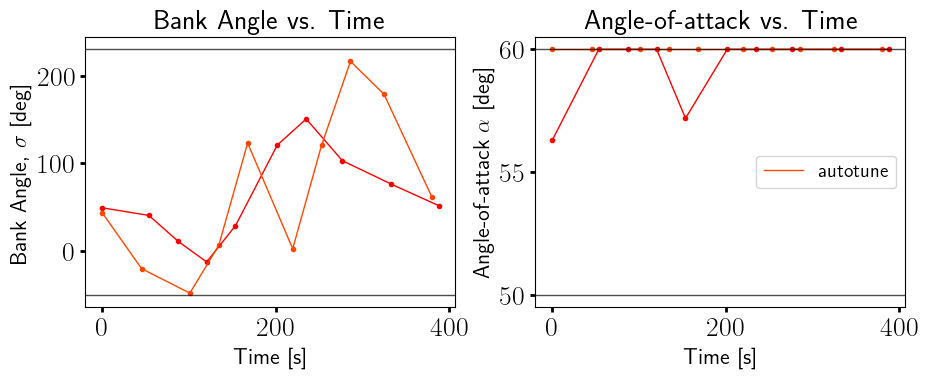

In [61]:
params = {}

grid = {};
grid[0] = [0.05,0.05,0.37,0.9]; grid[1] = [0.50,0.05,0.37,0.9];
params['grid'] = grid;

params['uselegend'] = [1];

makePlotCtrls2(PLTS1,ins={**plotparams,**params});

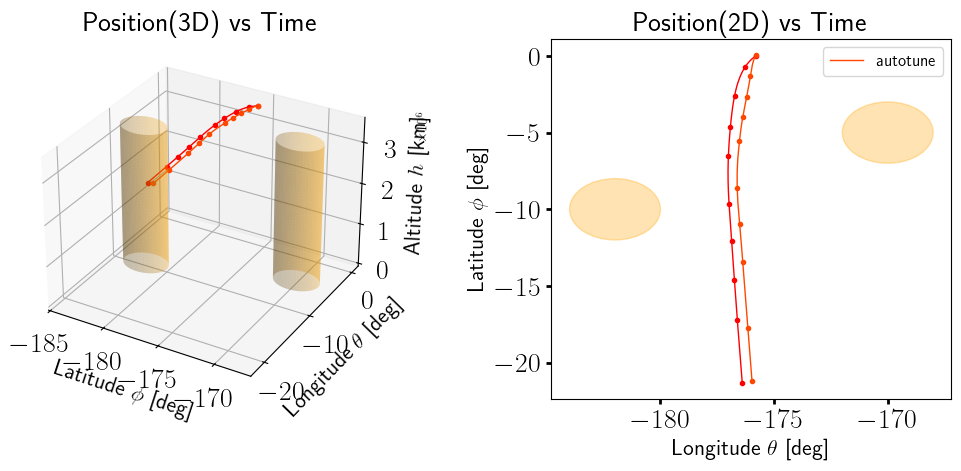

In [62]:
params = {}

grid = {};
grid[0] = [0.05,0.05,0.6,0.9]; grid[1] = [0.70,0.05,0.4,0.9];
params['grid'] = grid;

params['legendinfo'] = {'fontsize':12}

makePlotTrajs(PLTS1,ins={**plotparams,**params});

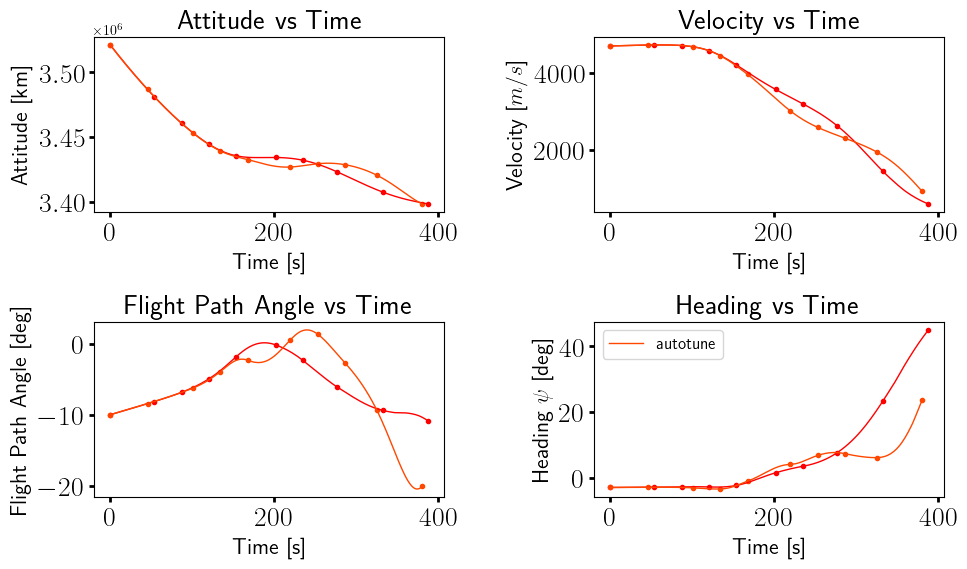

In [54]:
makePlotStates(PLTS1,ins=plotparams);

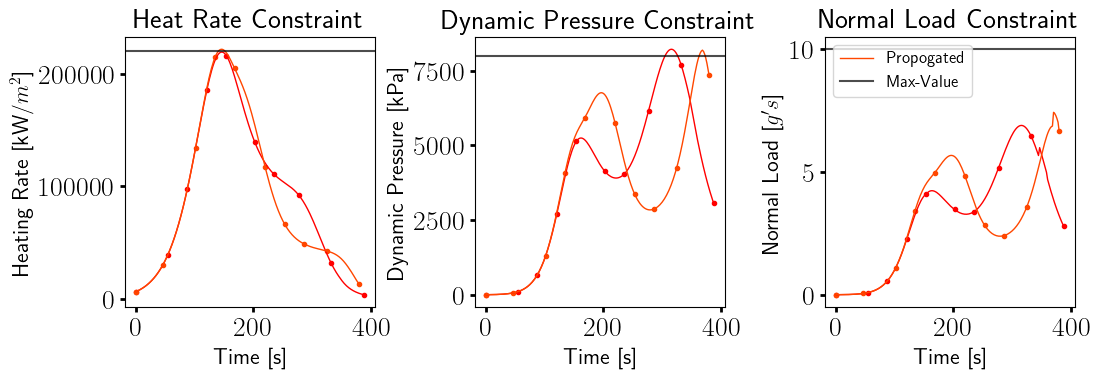

In [63]:
makePlotLoads(PLTS1,ins=plotparams);

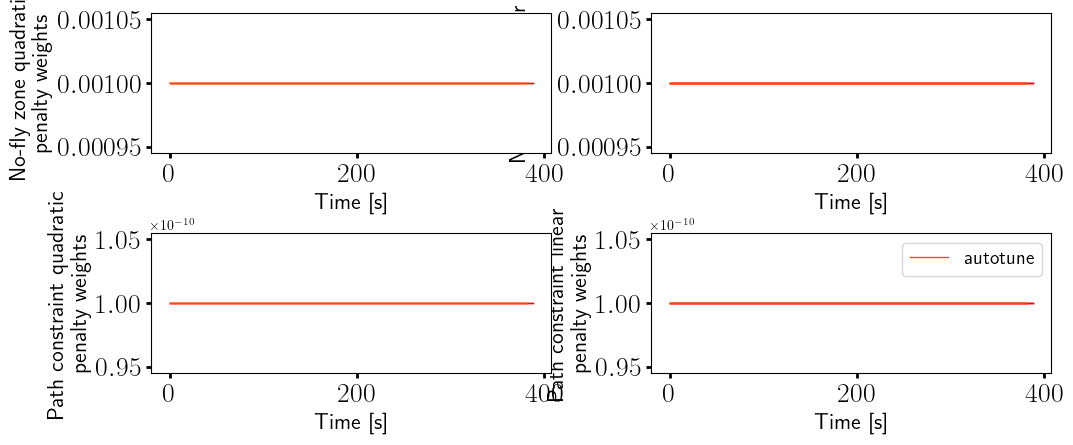

In [56]:
makePlotWghts(PLTS1,ins=plotparams);

IndexError: list index out of range

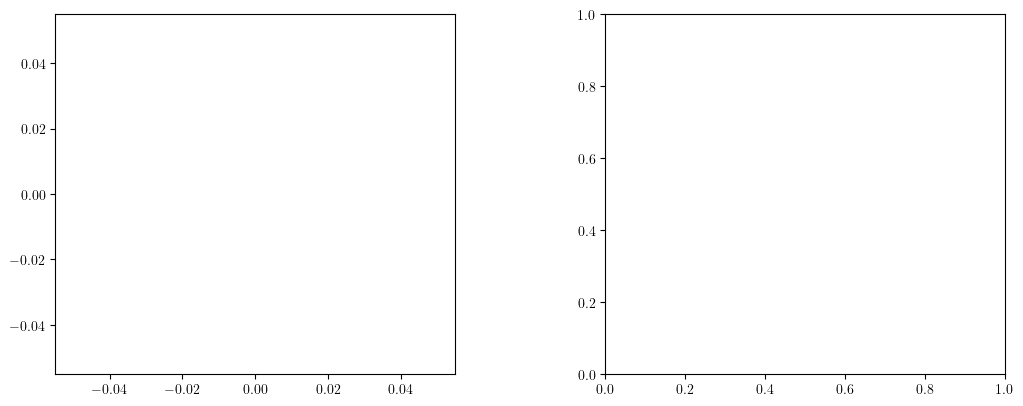

In [57]:
makePlotWghts2(PLTS1,ins=plotparams);

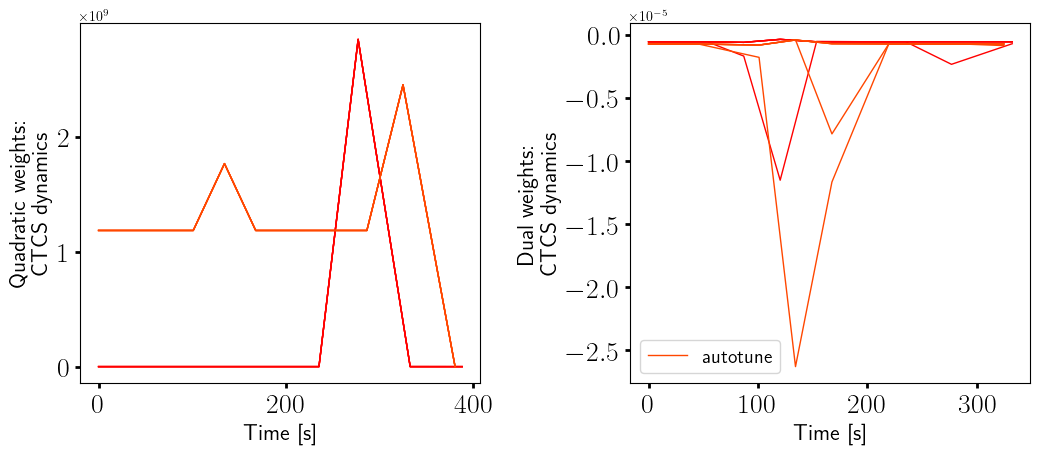

In [58]:
makePlotWghts3(PLTS1,ins=plotparams);

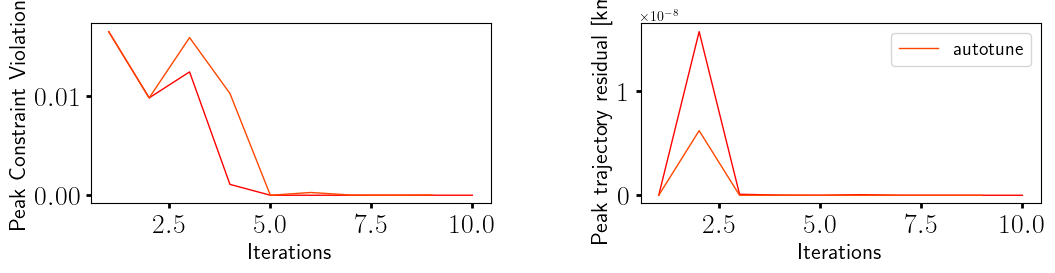

In [59]:
makePlotConvs(PLTS1,ins=plotparams);

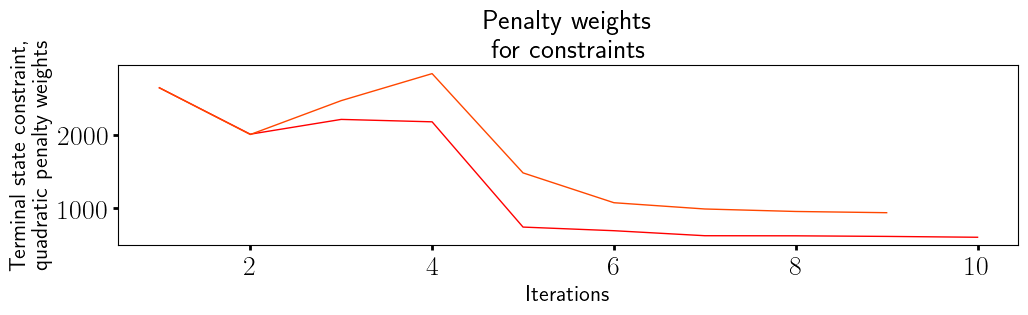

In [64]:
makePlotConvs2(PLTS1,ins=plotparams);

In [ ]:
makePlotConvs3(PLTS1,ins=plotparams);

# NOTES

In [ ]:
"""
params = {}
figsize = (10,5);
grid = {};
grid[0] = [0.05,0.6,0.4,0.35];  grid[1] = [0.55,0.6,0.4,0.35];
grid[2] = [0.05,0.05,0.4,0.35]; grid[3] = [0.55,0.05,0.4,0.35];
   
titles = {};
ylabels = {};
xlabels = {ind:'Time [s]' for ind in range(4)};
titles[0] = 'Attitude vs Time';
titles[1] = 'Velocity vs Time';
titles[2] = 'Flight Path Angle vs Time';
titles[3] = 'Heading vs Time';

ylabels[0] = 'Attitude [km]';
ylabels[1] = 'Velocity [$m/s$]';    
ylabels[2] = 'Flight Path Angle [deg]';
ylabels[3] = 'Heading $\psi$ [deg]';

params['titleinfo'] = {'fontsize':20,}
params['xlabelinfo'] = {'fontsize':20}
params['ylabelinfo'] = {'fontsize':20}
# params['ticksinfo'] = {'fontsize':20}
# params['legendinfo'] = {'fontsize':2}
params['uselegend'] = [0,1,3];

params['figsize'] = figsize; params['grid'] = grid;
params['titles'] = titles; params['xlabels'] = xlabels; params['ylabels'] = ylabels;
params['displayfigs'] = True;

makePlotStates(PLTS1,ins={**plotparams,**params});
"""